<a href="https://colab.research.google.com/github/roberthsu2003/machine_learning/blob/main/%E6%B1%BA%E7%AD%96%E6%A8%B9%E9%9B%86%E6%88%90%E6%A8%A1%E5%9E%8B/05_random_forest_heart_failure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 💡 環境檢查與 Colab 自動化設定 (Colab Setup)
import os
import urllib.request

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # 自動安裝 Colab 缺少之套件
    !pip install -q mglearn graphviz
    
    # 自動下載中文字型檔案 (ChineseFont.ttf) 與資料集
    font_url = "https://raw.githubusercontent.com/roberthsu2003/machine_learning/main/source_data/ChineseFont.ttf"
    data_url = "https://raw.githubusercontent.com/roberthsu2003/machine_learning/main/%E6%B1%BA%E7%AD%96%E6%A8%B9%E9%9B%86%E6%88%90%E6%A8%A1%E5%9E%8B/heart_failure_clinical_records_dataset.csv"
    if not os.path.exists("ChineseFont.ttf"):
        urllib.request.urlretrieve(font_url, "ChineseFont.ttf")
    if not os.path.exists("heart_failure_clinical_records_dataset.csv"):
        urllib.request.urlretrieve(data_url, "heart_failure_clinical_records_dataset.csv")


# 🌲 醫療案例：心臟衰竭病患生存風險預測（隨機森林 Random Forest 實戰）

心血管疾病是全球主要死因之一，其中**心臟衰竭（Heart Failure）** 發生於心臟無法輸送足夠血液至全身器官。在臨床重症照護中，若能提早辨識出病情惡化的高風險病患，醫師便能及時調整用藥或安排加護介入。

### 💡 隨機森林（Random Forest）在醫療診斷上的三大優勢：
1. **抗雜訊與強泛化能力**：醫療臨床數據通常包含許多個體生理差異與檢驗誤差，隨機森林透過 **自助抽樣（Bootstrap Aggregating, Bagging）** 建立 100 棵以上的決策樹並進行多數決投票，能顯著降低單一決策樹容易過擬合（Overfitting）的弱點。
2. **無需複雜特徵縮放**：決策樹模型對數值特徵的尺度不敏感，能同時良好地處理二元特徵（高血壓/糖尿病病史）與極端數值特徵（CPK 酵素、血小板數量）。
3. **客觀量化臨床特徵重要性（Feature Importance）**：能自動評估哪些檢驗指數（如肌酸酐、射血分數）對預測結果貢獻最大，提供高度可信的臨床決策輔助。

---

### 📊 臨床資料集特徵說明（`heart_failure_clinical_records_dataset.csv`）
來源：UCI 機器學習數據庫 / 《BMC Medical Informatics and Decision Making》
* **age**：病患年齡（歲）
* **anaemia**：是否貧血（0: 否, 1: 是）
* **creatinine_phosphokinase**：肌酸磷酸激酶 CPK 酵素（mcg/L）
* **diabetes**：是否有糖尿病史（0: 否, 1: 是）
* **ejection_fraction**：心臟射血分數 EF（每次心縮泵出血液的百分比 %）
* **high_blood_pressure**：是否有高血壓史（0: 否, 1: 是）
* **platelets**：血液中的血小板數量（kiloplatelets/mL）
* **serum_creatinine**：血清肌酸酐濃度（mg/dL，評估腎功能與器官衰竭的核心指標）
* **serum_sodium**：血清鈉離子濃度（mEq/L）
* **sex**：生理性別（0: 女性, 1: 男性）
* **smoking**：是否抽菸（0: 否, 1: 是）
* **time**：臨床追蹤觀察期（天數）
* **目標變數 (DEATH_EVENT)**：病患是否在追蹤期間死亡（`0: 存活`, `1: 病逝 / 高危險群`）


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 中文字型設定
font_path = "ChineseFont.ttf" if os.path.exists("ChineseFont.ttf") else "../source_data/ChineseFont.ttf"
if os.path.exists(font_path):
    font_prop = fm.FontProperties(fname=font_path)
    plt.rcParams["font.sans-serif"] = [font_prop.get_name()]
    plt.rcParams["axes.unicode_minus"] = False
else:
    font_prop = None

# 讀取心臟衰竭資料集
data_file = "heart_failure_clinical_records_dataset.csv" if os.path.exists("heart_failure_clinical_records_dataset.csv") else "決策樹集成模型/heart_failure_clinical_records_dataset.csv"
df = pd.read_csv(data_file)

print(f"資料筆數: {df.shape[0]} 筆，特徵欄位數: {df.shape[1]} 個")
print("\n前 5 筆臨床資料：")
display(df.head())
print("\n目標標籤分佈：")
print(df["DEATH_EVENT"].value_counts().rename({0: "存活 (0)", 1: "死亡 (1)"}))


資料筆數: 299 筆，特徵欄位數: 13 個

前 5 筆臨床資料：


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1



目標標籤分佈：
DEATH_EVENT
存活 (0)    203
死亡 (1)     96
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 定義特徵與標籤 (排除追蹤天數 time，專注於入院時之生理與生化指標)
feature_names_en = [
    'age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
    'ejection_fraction', 'high_blood_pressure', 'platelets',
    'serum_creatinine', 'serum_sodium', 'sex', 'smoking'
]

feature_names_zh = [
    '年齡 (age)', '貧血 (anaemia)', '肌酸激酶 (CPK)', '糖尿病 (diabetes)',
    '射血分數 (ejection_fraction)', '高血壓 (high_blood_pressure)', '血小板 (platelets)',
    '血清肌酸酐 (serum_creatinine)', '血清鈉 (serum_sodium)', '性別 (sex)', '抽菸 (smoking)'
]

X = df[feature_names_en]
y = df['DEATH_EVENT']

# 切分訓練集 (75%) 與測試集 (25%)，並進行分層抽樣 (stratify)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print(f"訓練集樣本數: {X_train.shape[0]}，測試集樣本數: {X_test.shape[0]}")


訓練集樣本數: 224，測試集樣本數: 75


### 🚀 訓練 100 棵決策樹組成的隨機森林分類器

In [4]:
# 建立隨機森林模型
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

train_acc = rf.score(X_train, y_train)
test_acc = rf.score(X_test, y_test)

print(f"隨機森林在訓練集的準確率: {train_acc:.3f}")
print(f"隨機森林在測試集的準確率: {test_acc:.3f}")


隨機森林在訓練集的準確率: 1.000
隨機森林在測試集的準確率: 0.760


### 🔧 調整參數抑制過擬合（預修剪 Pre-pruning）
預設的隨機森林樹深沒有限制（`max_depth=None`），因此在訓練集上通常能達到近乎 100% 的準確率。我們可以透過限制 `max_depth` 與 `min_samples_split` 來進行預剪枝，提升模型的泛化能力。


In [5]:
# 預剪枝調整
rf_pruned = RandomForestClassifier(n_estimators=100, max_depth=4, min_samples_split=5, random_state=42)
rf_pruned.fit(X_train, y_train)

print(f"預剪枝後訓練集準確率: {rf_pruned.score(X_train, y_train):.3f}")
print(f"預剪枝後測試集準確率: {rf_pruned.score(X_test, y_test):.3f}")


預剪枝後訓練集準確率: 0.853
預剪枝後測試集準確率: 0.747


### 📈 臨床評估指標（混淆矩陣與 ROC 曲線）

findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


/Users/roberthsu2003/Documents/GitHub/machine_learning/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 38928 (\N{CJK UNIFIED IDEOGRAPH-9810}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/roberthsu2003/Documents/GitHub/machine_learning/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/roberthsu2003/Documents/GitHub/machine_learning/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 23384 (\N{CJK UNIFIED IDEOGRAPH-5B58}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/roberthsu2003/Documents/GitHub/machine_learning/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 27963 (\N{CJK UNIFIED IDEOGRAPH-6D3B}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFo

findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


/Users/roberthsu2003/Documents/GitHub/machine_learning/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 27515 (\N{CJK UNIFIED IDEOGRAPH-6B7B}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/roberthsu2003/Documents/GitHub/machine_learning/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 20129 (\N{CJK UNIFIED IDEOGRAPH-4EA1}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


...

findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


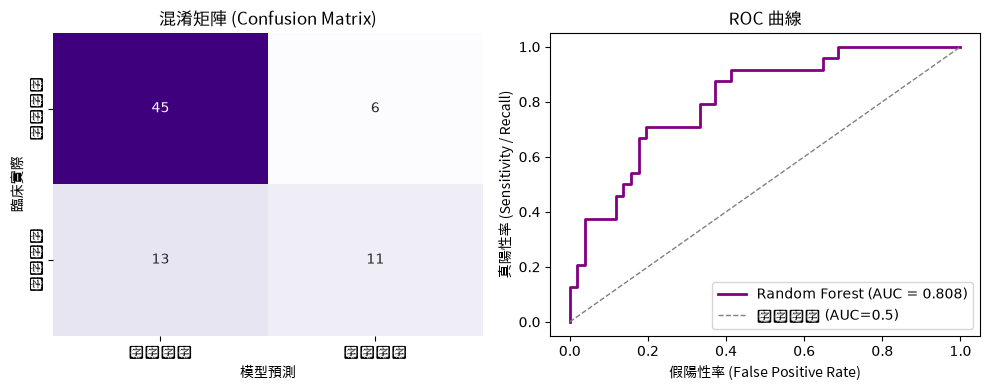


臨床分類評估報告：
              precision    recall  f1-score   support

          存活       0.78      0.88      0.83        51
       高風險死亡       0.65      0.46      0.54        24

    accuracy                           0.75        75
   macro avg       0.71      0.67      0.68        75
weighted avg       0.73      0.75      0.73        75



In [6]:
y_pred = rf_pruned.predict(X_test)
y_prob = rf_pruned.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
auc_val = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", cbar=False,
            xticklabels=["預測存活", "預測死亡"],
            yticklabels=["實際存活", "實際死亡"])
plt.title("混淆矩陣 (Confusion Matrix)", fontproperties=font_prop, fontsize=12)
plt.xlabel("模型預測", fontproperties=font_prop)
plt.ylabel("臨床實際", fontproperties=font_prop)

from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color="purple", lw=2, label=f"Random Forest (AUC = {auc_val:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="隨機基準 (AUC=0.5)")
plt.xlabel("假陽性率 (False Positive Rate)", fontproperties=font_prop)
plt.ylabel("真陽性率 (Sensitivity / Recall)", fontproperties=font_prop)
plt.title("ROC 曲線", fontproperties=font_prop, fontsize=12)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

print("\n臨床分類評估報告：")
print(classification_report(y_test, y_pred, target_names=["存活", "高風險死亡"]))


### 📊 隨機森林特徵重要性（Feature Importance）分析

隨機森林能夠透過統計森林中所有樹在節點分裂時對不純度（Gini Impurity）的總減少量，客觀計算出每個臨床變數的**特徵重要性**。這在醫學分析上具有極高的臨床參考價值。


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


...

findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


findfont: Generic family 'sans-serif' not found because none of the following families were found: ChineseFont


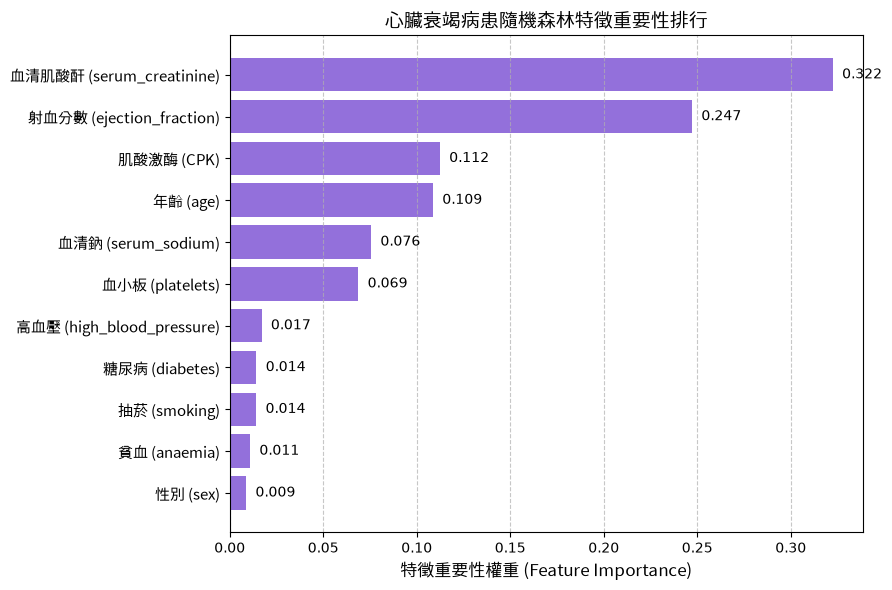

In [7]:
# 提取特徵重要性
importances = rf_pruned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(9, 6))
plt.barh(range(len(indices)), importances[indices], color='mediumpurple', align='center')
plt.yticks(range(len(indices)), [feature_names_zh[i] for i in indices], fontproperties=font_prop, fontsize=11)
plt.xlabel('特徵重要性權重 (Feature Importance)', fontproperties=font_prop, fontsize=12)
plt.title('心臟衰竭病患隨機森林特徵重要性排行', fontproperties=font_prop, fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# 數值標籤
for i, v in enumerate(importances[indices]):
    plt.text(v + 0.005, i, f"{v:.3f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()


### 🩺 醫學統計與臨床價值解讀
1. **血清肌酸酐（serum_creatinine）與心臟射血分數（ejection_fraction）為前兩大核心指標**：
   * **血清肌酸酐**：代表腎臟灌流與代謝功能，心腎綜合症候群（Cardiorenal Syndrome）常導致心衰竭病患併發腎衰竭，為死亡之關鍵警訊。
   * **射血分數**：直接反映左心室收縮泵血能力，低射血分數是嚴重心臟衰竭的病理特徵。
   * 這完全吻合頂級醫學期刊《BMC Medical Informatics》2020 年的權威結論（Davide Chicco & Giuseppe Jurman: *"Machine learning can predict survival of patients with heart failure from serum creatinine and ejection fraction alone"*）。
2. **年齡（age）與肌酸激酶（CPK）次之**：高齡及心肌細胞受損釋放的 CPK 酵素亦佔有穩定之預測權重。
3. **隨機森林展現強大的可解釋性**：相比黑盒子神經網路，隨機森林能清楚給出各項臨床化驗因子的權重順序，大幅增進臨床醫師對 AI 輔助診斷系統的信任度。
